In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Standard library
import gc
import logging
from pathlib import Path

import shap
import xgboost as xgb
from dask.distributed import Client, LocalCluster
from Experiment import Experiment
from newutils.data.Dataset import Dataset
from newutils.other.helpers import init_context
from oldutils.types import TimeRange

init_context()

In [ ]:
# import geopandas
# gdf = geopandas.read_file("data/GTS_river_gauges.gpkg")
# gdf

In [3]:
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [4]:
HORIZON_HISTORY = TimeRange.YEAR
HORIZON_FORECAST = TimeRange.WEEK
PARTITION_SIZE = "50MB"
N_WORKERS = 1

COL_GAUGE_ID = "gauge_id"
TARGETS = ["q_mm_day"]

In [5]:
cluster = LocalCluster(
    dashboard_address=":8789",
    asynchronous=False,
    n_workers=N_WORKERS,
    threads_per_worker=1,
    memory_limit="6GB",
)
client = Client(cluster)

2025-05-13 21:37:38,352 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:37333 (pid=1118967) exceeded 95% memory budget. Restarting...
2025-05-13 21:37:38,832 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:37333' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('astype-3dfe3a13056ea85cf0673e2e8229e87b', 222), 'dict-bf2eb00a-aa8c-40c8-aad8-f4a25fc22435', ('astype-b1a013ef0e5861747942170957f87d0a', 138), 'dict-31fc231b-ccf8-4eee-a059-c8e609e57061', ('astype-3dfe3a13056ea85cf0673e2e8229e87b', 231), ('astype-3dfe3a13056ea85cf0673e2e8229e87b', 2), ('astype-b1a013ef0e5861747942170957f87d0a', 147), ('astype-3dfe3a13056ea85cf0673e2e8229e87b', 240), ('astype-b1a013ef0e5861747942170957f87d0a', 156), ('astype-3dfe3a13056ea85cf0673e2e8229e87b', 249), ('astype-3dfe3a13056ea85cf0673e2e8229e87b', 258), 'dict-536063a7-c6ea-490e-8bba-cd07c40bf35c', ('repartitionsize-91673b210d7dc86f7748092652ec9abe', 186), ('repartitionsize-91

In [6]:
outpath = Path("artifacts")
outpath.mkdir(parents=True, exist_ok=True)
dataset = Dataset(client)
dataset.create(num_load=100)

2025-05-13 21:08:44,899 - newutils.data.Dataset - INFO - Create dataframe.
2025-05-13 21:08:44,900 - newutils.data.Dataset - INFO - Load time series.
2025-05-13 21:08:44,931 - newutils.data.Dataset - WARNING - DEBUG: frac=0.1


2025-05-13 21:08:44,931 - newutils.data.Dataset - INFO - Persist.
2025-05-13 21:08:46,863 - newutils.data.Dataset - INFO - Generate lags features.
2025-05-13 21:08:48,650 - newutils.data.Dataset - INFO - Make repartition (100MB).
2025-05-13 21:08:48,651 - newutils.data.Dataset - INFO - Persist.
2025-05-13 21:16:14,467 - newutils.data.Dataset - INFO - Clear dataset from nans.
2025-05-13 21:16:14,885 - newutils.data.Dataset - INFO - Add static features.
2025-05-13 21:16:14,897 - newutils.data.Dataset - INFO - Load static features.
2025-05-13 21:16:16,338 - newutils.data.Dataset - INFO - Make repartition (30MB).
2025-05-13 21:16:16,344 - newutils.data.Dataset - INFO - Persist.


In [7]:
dataset.df.map_partitions(lambda pdf: pdf.memory_usage(deep=True).sum()).compute().sum()

7423433552

In [8]:
experiment = Experiment(client, outpath, dataset)

In [ ]:
params = {
    "tree_method": "hist",
    "learning_rate": 0.001,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 1,
    "eval_metric": "mape",
    "num_boost_round": 100,
    "verbose_eval": 10,
    "n_jobs": -1,
    "num_load": 100,
    "partition_size": "100MB",
}

experiment.make(params)

2025-05-13 21:26:24,557 - Experiment - INFO - Prepare experiment.
2025-05-13 21:26:24,559 - newutils.data.Dataset - INFO - Make train test split to X and y.


2025-05-13 21:30:56,438 - Experiment - WARNING - DEBUG: Use only one feature to predict.
2025-05-13 21:30:56,453 - newutils.data.Dataset - INFO - Create XGBoost DaskDMatrix.
2025-05-13 21:36:50,528 - Experiment - INFO - Start model training.
[21:37:33] Task [xgboost.dask-0]:tcp://127.0.0.1:37333 got rank 0
2025-05-13 21:37:35,640 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 4.52 GiB -- Worker memory limit: 5.59 GiB


KeyboardInterrupt: 

2025-05-13 21:41:39,282 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
  File "/usr/lib/python3.11/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/asyncio/base_events.py", line 654, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/distributed/core.py", line 494, in finished
    await self._event_finished.wait()
  File "/usr/lib/python3.11/asyncio/locks.py", line 213, in wait
    await fut
asyncio.exceptions.CancelledError

During handling of the above exception, another e

In [ ]:
# client.close()
# cluster.close()
# gc.collect()

In [ ]:
dataset = Dataset(client)
dataset.create(num_load=1)

2025-05-13 10:46:54,866 - newutils.data.Dataset - INFO - Create dataframe.
2025-05-13 10:46:54,870 - newutils.data.Dataset - INFO - Load time series.
2025-05-13 10:46:55,121 - newutils.data.Dataset - WARNING - DEBUG: frac=0.1
2025-05-13 10:46:55,123 - newutils.data.Dataset - INFO - Persist.
2025-05-13 10:46:55,224 - newutils.data.Dataset - INFO - Persist.
2025-05-13 10:46:55,248 - newutils.data.Dataset - INFO - Generate lags features.
2025-05-13 10:46:56,960 - newutils.data.Dataset - INFO - Make repartition (100MB).
2025-05-13 10:46:56,966 - newutils.data.Dataset - INFO - Persist.
2025-05-13 10:47:01,226 - newutils.data.Dataset - INFO - Clear dataset from nans.
2025-05-13 10:47:01,229 - newutils.data.Dataset - INFO - Add static features.
2025-05-13 10:47:01,229 - newutils.data.Dataset - INFO - Load static features.
2025-05-13 10:47:01,656 - newutils.data.Dataset - INFO - Persist.
2025-05-13 10:47:04,282 - newutils.data.Dataset - INFO - Make repartition (100MB).
2025-05-13 10:47:04,285 

In [ ]:
X_test, y_test, _, _ = dataset.train_test_Xy_split()
y_test = y_test[Dataset.TARGET]

2025-05-13 10:47:12,198 - newutils.data.Dataset - INFO - Make train test split to X and y.


In [ ]:
booster = xgb.Booster()
booster.load_model(experiment.model_paths[-1])

In [ ]:
gc.collect()

1829

In [ ]:
explainer = shap.TreeExplainer(booster) #, experiment.X_train.compute())

In [ ]:
shap_values = explainer.shap_values(X_test.sample(frac=0.1).compute(), y_test.sample(frac=0.1).compute())

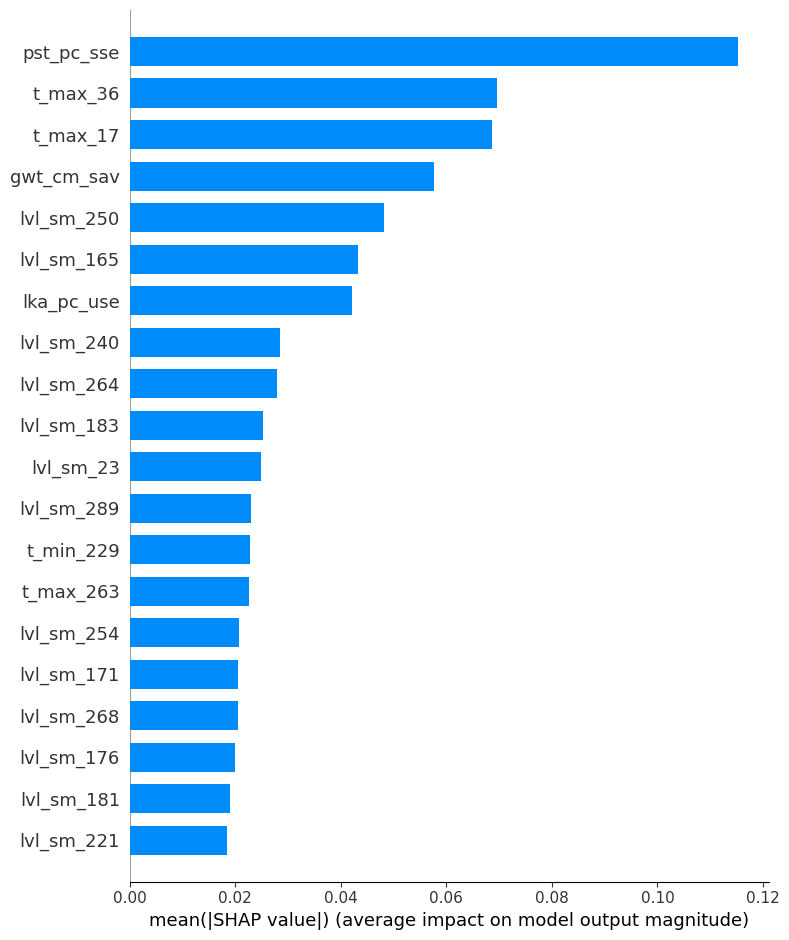

In [ ]:
shap.summary_plot(shap_values, X_test.compute(), plot_type="bar")

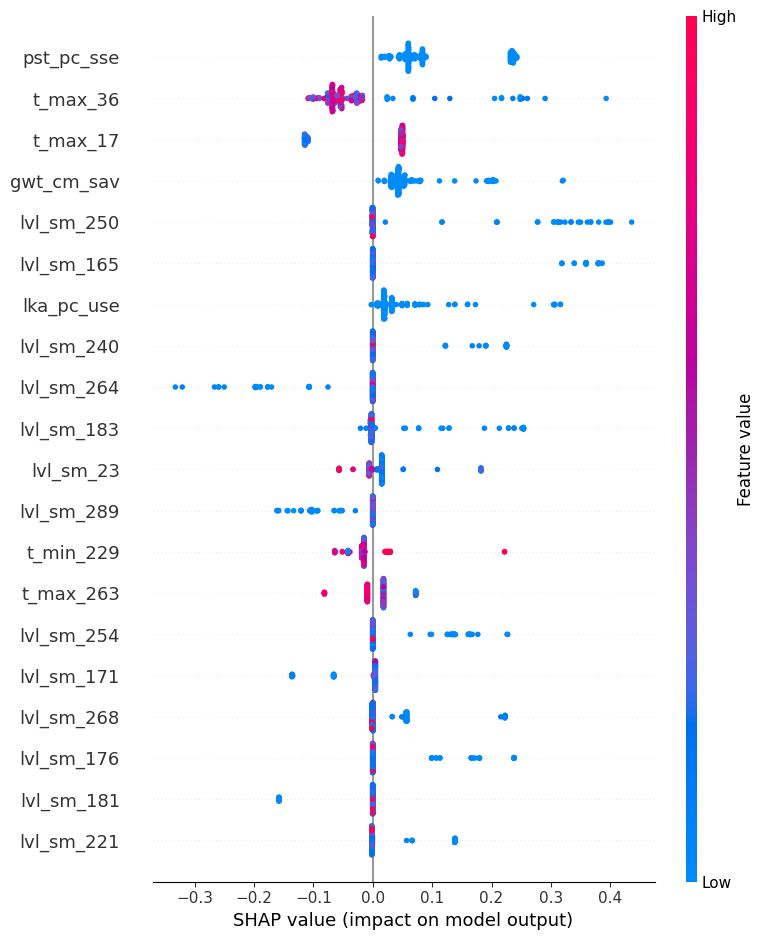

In [ ]:
shap.summary_plot(shap_values, X_test.compute())